In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# build dataset
words = open('../data/names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
# Vocabulary
chars = sorted(list(set(''.join(words))))
# We have a mapping for all characters
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}

In [5]:
# build dataset, we increase the bigrams into ngrams
# it is configurable by the block size

block_size = 3 # context length
X, Y = [], []
for w in words[:5]:

    print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix] # crop context and append in a rolling window
    print('------')

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
------
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
------
ava
... --> a
..a --> v
.av --> a
ava --> .
------
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
------
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .
------


In [6]:
X = torch.tensor(X)
Y = torch.tensor(Y)

In [7]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [8]:
C = torch.randn((27, 2)) # we create an embedding for 27 letters into 2 embeddings

In [9]:
# we one hot encode each class and do a matrix mult with the C embedding
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C

tensor([ 1.1589, -0.7776])

In [10]:
# But we can do that easily by just passing a list of the rows classes into C
emb = C[X]

In [11]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [12]:
# emb @ W1 + b1 # -> this does not work # RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [13]:
# this does not scale, but is a way to do it
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [14]:
# unbind lets you do the same thing inefficiently, but scalable
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 6])

In [15]:
# this is way better
emb.view(-1, 6).shape 

torch.Size([32, 6])

In [16]:
h = (emb.view(emb.shape[0], 6) @ W1) + b1

In [17]:
h

tensor([[-2.4150, -1.5980, -0.0710,  ...,  2.6336, -2.0601,  0.5538],
        [-5.9723, -2.1803,  1.5501,  ..., -0.1048, -0.5147,  1.5620],
        [-1.3518,  0.8653, -1.1660,  ...,  1.0720,  4.5395, -0.7683],
        ...,
        [-5.2823,  0.8892, -0.2225,  ..., -1.4542,  1.8807,  3.7454],
        [-1.1765,  1.5178, -0.6881,  ...,  2.2094, -0.6888,  2.7914],
        [ 4.5694, -0.8103,  1.2646,  ...,  5.9112, -6.7768,  2.0518]])

In [18]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)


In [19]:
logits = (h @ W2) + b2

In [20]:
probs = F.softmax(logits, dim=1)

In [21]:
probs.shape

torch.Size([32, 27])

In [22]:
probs[torch.arange(32), Y] # we get the probabilities of the labels

tensor([3.7964e-16, 3.5947e-27, 2.7430e-20, 0.0000e+00, 9.7899e-33, 2.8981e-18,
        2.4720e-09, 4.0955e-14, 2.5967e-21, 4.0058e-12, 9.5060e-06, 1.3297e-13,
        2.4019e-20, 5.8183e-26, 0.0000e+00, 2.4850e-24, 7.1482e-20, 1.0241e-01,
        1.4764e-21, 1.5765e-05, 2.0839e-21, 6.2883e-28, 1.5065e-14, 1.0288e-20,
        2.7772e-10, 1.3569e-01, 1.6341e-23, 8.2688e-23, 9.5557e-31, 6.8053e-09,
        1.9734e-09, 2.7876e-21])

In [ ]:
loss = -probs[torch.arange(32), Y].log().mean()
loss
# underflow on float32

tensor(inf)

In [ ]:
logits.max(), logits.min()
# we need to change the approach, read some documentation, we can avoid using probs and just use softmax
# comment 2: Karpathy was not using tanh on the first explanation, so the data range was gigantic and casued an underflow.

(tensor(114.2459), tensor(-88.3742))

In [29]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator = g)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn(100 , generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn(27, generator = g)
parameters = [C, W1, b1, W2, b2]

In [30]:
sum(p.nelement() for p in parameters) 

3481

In [ ]:
# Forward
size = emb.shape[0]

emb = C[X]
h = torch.tanh((emb.view(size, 6) @ W1) + b1)
logits = (h @ W2) + b2
counts = logits.exp()
prob = counts / counts.sum(1, keepdim = True)
loss = -prob[torch.arange(size), Y].log().mean()

In [32]:
loss

tensor(17.7697)

In [140]:
# build dataset, we increase the bigrams into ngrams
# it is configurable by the block size

block_size = 4 # context length
X, Y = [], []
for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '-->', itos[ix])
        context = context[1:] + [ix] # crop context and append in a rolling window
    #print('------')

X = torch.tensor(X)
Y = torch.tensor(Y)

In [141]:
X

tensor([[ 0,  0,  0,  0],
        [ 0,  0,  0,  5],
        [ 0,  0,  5, 13],
        ...,
        [ 0, 26, 26, 25],
        [26, 26, 25, 26],
        [26, 25, 26, 24]])

In [155]:
import math

In [171]:
# initialize params
embedding_size = 12
hidden_layer = 300
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embedding_size), generator = g, requires_grad=True)
W1 = torch.randn((block_size*embedding_size, hidden_layer), generator = g, requires_grad=True)
b1 = torch.randn(hidden_layer , generator = g, requires_grad=True)
W2 = torch.randn((hidden_layer, vocab_size), generator = g, requires_grad=True)
b2 = torch.randn(vocab_size, generator = g, requires_grad=True)
parameters = [C, W1, b1, W2, b2]

# gradient descent
losses = []

for k in range(10000):

    # we can do mini batches to sample and not have all the data go through
    ix = torch.randint(0, X.shape[0], (256,))

    # Forward pass
    emb = C[X[ix]]
    size = emb.shape[0]
    
    h = torch.tanh((emb.view(size, block_size*embedding_size) @ W1) + b1)
    logits = (h @ W2) + b2
    #counts = logits.exp()
    #prob = counts / counts.sum(1, keepdim = True)
    #loss = -prob[torch.arange(size), Y].log().mean()
    loss = F.cross_entropy(logits, Y[ix])

    losses.append(loss.item())

    # We reset the gradients, we can use 0 or use None (which is more efficient)
    for parameter in parameters:
        parameter.grad = None

    loss.backward()

    for parameter in parameters:
        parameter.data += -0.1 * math.exp(-k/2000) * parameter.grad

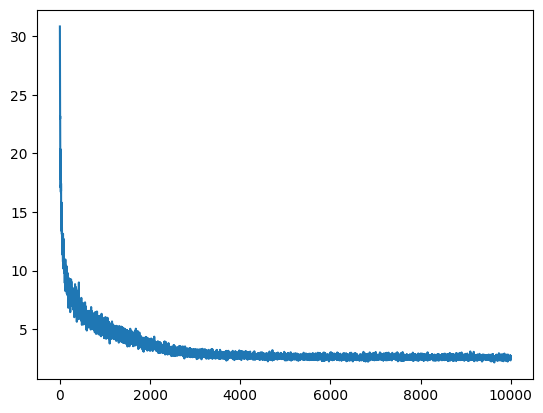

In [172]:
plt.plot(losses)

In [175]:
torch.tensor(losses).min()

tensor(2.1659)

In [174]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):

    out = []
    context = [0] * block_size

    while True:

        # Forward pass
        embd = C[torch.tensor([context])]          
        h = torch.tanh(embd.view(1, -1) @ W1 + b1) 
        logits = h @ W2 + b2                      
        probs = F.softmax(logits, dim=1)

        # Sample next character
        ix = torch.multinomial(
            probs.squeeze(0),
            num_samples=1,
            generator=g
        ).item()

        out.append(itos[ix])

        if ix == 0:
            break

        # Slide the context window
        context = context[1:] + [ix]

    print(''.join(out))

dextan.
jaliurailen.
taha.
konima.
tainrlen.
kamaria.
samirah.
javhi.
gatmie.
czise.
